# TabNet PEAD — Trading Strategy Backtest

Buy when predicted class is 1 or 2. Exit at take-profit threshold or t+10 close.

## Strategy 1
Sweep thresholds 1%–5% (step 0.5%). For each: exit at threshold if stock ever reaches it,
otherwise at t+10 close. Cash-constrained: trades only open if capital available.
Pick best threshold by Sharpe.

## Strategy 2
Use best threshold from Strat 1. Sell half position at half-threshold, remaining
half at full threshold (or t+10 if never hit).

## Rules
- Initial capital: $50,000 · Position size: $100 per trade
- Entry at t+1 close · Exit on the exact calendar day threshold is crossed
- Cash constraint: cannot enter if deployed capital already equals cash
- Equity curve: P&L aggregated by sell date, daily return = P&L / initial capital,
  portfolio value compounds daily

In [56]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [57]:
# ── Paths (try repo-root relative first, then notebook-relative) ──────
RESULTS_PATH = Path("src/modeling/modal_tabnet_outputs/results.parquet")
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("modal_tabnet_outputs/results.parquet")

DAILY_PATH = Path("src/data/model_staging/tech_daily_table.parquet")
if not DAILY_PATH.exists():
    DAILY_PATH = Path("../data/model_staging/tech_daily_table.parquet")

# ── Strategy params ───────────────────────────────────────────────────
INITIAL_CAPITAL = 50_000
POSITION_SIZE = 200
THRESHOLDS = np.arange(0.01, 0.0525, 0.005)  # 1% to 5%, step 0.5%

# ── Daily high window: t+2 to t+10 (9 trading days) ──────────────────
DRIFT_OFFSETS = list(range(2, 11))  # [2, 3, ..., 10]

---
## 1. Load & merge data

In [58]:
# ── Load results, filter to buy signals ───────────────────────────────
results = pl.read_parquet(RESULTS_PATH)
signals = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
print(f"Buy signals: {len(signals):,}")

# ── Load daily OHLCV, add forward high/date/close columns ─────────────
daily = pl.read_parquet(DAILY_PATH).select(["symbol", "date", "high", "close"])
daily = daily.sort(["symbol", "date"])

# Forward shifts for drift window (t+2 .. t+10)
for offset in DRIFT_OFFSETS:
    daily = daily.with_columns([
        pl.col("high").shift(-offset).over("symbol").alias(f"high_t+{offset}"),
        pl.col("date").shift(-offset).over("symbol").alias(f"date_t+{offset}"),
    ])

# Entry date (t+1) and close at t+10
daily = daily.with_columns([
    pl.col("date").shift(-1).over("symbol").alias("entry_date"),
    pl.col("close").shift(-10).over("symbol").alias("close_t10"),
])

# ── Join drift + entry data onto signals ─────────────────────────────
join_cols = ["symbol", "date", "entry_date", "close_t10"]
for offset in DRIFT_OFFSETS:
    join_cols += [f"high_t+{offset}", f"date_t+{offset}"]

signals = signals.join(
    daily.select(join_cols),
    left_on=["symbol", "earnings_date"], right_on=["symbol", "date"], how="left",
)
signals = signals.with_columns(
    (pl.col("close_t10") / pl.col("entry_price") - 1).alias("close_t10_return")
)
print(f"After join — rows: {len(signals)}, null close_t10: {signals['close_t10_return'].null_count()}")

Buy signals: 8,221
After join — rows: 8221, null close_t10: 0


In [59]:
# ── Extract numpy arrays for vectorised threshold sweep ───────────────
HIGH_COLS = [f"high_t+{d}" for d in DRIFT_OFFSETS]
DATE_COLS = [f"date_t+{d}" for d in DRIFT_OFFSETS]

drift_highs = np.column_stack([signals[c].to_numpy() for c in HIGH_COLS])  # (N, 9)
drift_dates = np.column_stack([signals[c].to_numpy() for c in DATE_COLS])  # (N, 9)
entry_prices = signals["entry_price"].to_numpy()
close_t10_ret = signals["close_t10_return"].to_numpy()
close_t10_date = drift_dates[:, -1]
entry_dates = signals["entry_date"].to_numpy().astype("datetime64[D]")
N = len(signals)

# ── Cummax return during drift window per trade ───────────────────────
drift_rets = drift_highs / entry_prices[:, None] - 1
cummax_rets = np.maximum.accumulate(drift_rets, axis=1)

print(f"Ready — {N} trades, {len(DRIFT_OFFSETS)} drift days, {len(THRESHOLDS)} thresholds")

Ready — 8221 trades, 9 drift days, 9 thresholds


---
## 2. Signal Quality

In [60]:
buy_all = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
overall_win = (buy_all["target_class_actual"] >= 1).mean()
print(f"Overall directional win % (actual >= 1): {overall_win:.2%}")
print(f"\n{'Pred':<6} {'Count':>7} {'Win% (≥1)':>11} {'Hit 2%':>8} {'AvgRet':>8}"
      f" {'Low(0)':>7} {'Mod(1)':>7} {'Str(2)':>7}")
print(f"{'-'*65}")
for p in [0, 1, 2]:
    sub = results.filter(pl.col("target_class_predicted") == p)
    win = (sub["target_class_actual"] >= 1).mean()
    hit2 = (sub["target_return_actual"] > 0.02).mean()
    a0, a1, a2 = [(sub["target_class_actual"] == c).sum() for c in [0, 1, 2]]
    print(f"{p:<6} {len(sub):>7,} {win:>11.2%} {hit2:>8.2%}"
          f" {sub['target_return_actual'].mean():>8.2%} {a0:>7} {a1:>7} {a2:>7}")

Overall directional win % (actual >= 1): 72.59%

Pred     Count   Win% (≥1)   Hit 2%   AvgRet  Low(0)  Mod(1)  Str(2)
-----------------------------------------------------------------
0        1,716      63.99%   63.99%    3.58%     618     504     594
1        2,290      67.07%   67.07%    3.77%     754     688     848
2        5,931      74.73%   74.73%    5.34%    1499    1395    3037


---
## 3. Strategy 1 — Threshold Sweep

In [61]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap):
    """Aggregate P&L by sell date, compound equity curve."""
    dates_py = sell_date.tolist()  # numpy datetime64 -> Python date objects
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()
    daily_rets = pnl_vals / initial_cap
    equity = initial_cap * (1 + daily_rets).cumprod()
    return dates, daily_rets, equity
    pnl_vals = daily_pnl["pnl"].to_numpy()
    daily_rets = pnl_vals / initial_cap
    equity = initial_cap * (1 + daily_rets).cumprod()
    return dates, daily_rets, equity


def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL)
    sr = sharpe_annualised(daily_rets)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
    })
    print(f"  T={T:4.1%}  Sharpe={sr:6.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}")

  T=1.0%  Sharpe=  1.27  P&L=$   2,868  Win=86.2%  Sk=0
  T=1.5%  Sharpe=  1.77  P&L=$   4,921  Win=80.6%  Sk=0
  T=2.0%  Sharpe=  2.07  P&L=$   6,637  Win=75.9%  Sk=0
  T=2.5%  Sharpe=  2.20  P&L=$   7,903  Win=71.5%  Sk=0
  T=3.0%  Sharpe=  2.10  P&L=$   8,436  Win=67.5%  Sk=0
  T=3.5%  Sharpe=  2.19  P&L=$   9,531  Win=65.0%  Sk=0
  T=4.0%  Sharpe=  2.23  P&L=$  10,298  Win=63.0%  Sk=0
  T=4.5%  Sharpe=  2.32  P&L=$  11,309  Win=61.7%  Sk=7
  T=5.0%  Sharpe=  2.33  P&L=$  12,138  Win=60.7%  Sk=13


In [62]:
# ── Select best threshold by Sharpe ───────────────────────────────────
best_idx = max(range(len(results_s1)), key=lambda i: results_s1[i]["sharpe"])
best = results_s1[best_idx]
BEST_T = best["threshold"]
print(f"\nBest threshold: {BEST_T:.1%}  (Sharpe: {best['sharpe']:.2f}, "
      f"P&L: ${best['total_pnl']:,.0f}, Skipped: {best['n_skipped']})")


Best threshold: 5.0%  (Sharpe: 2.33, P&L: $12,138, Skipped: 13)


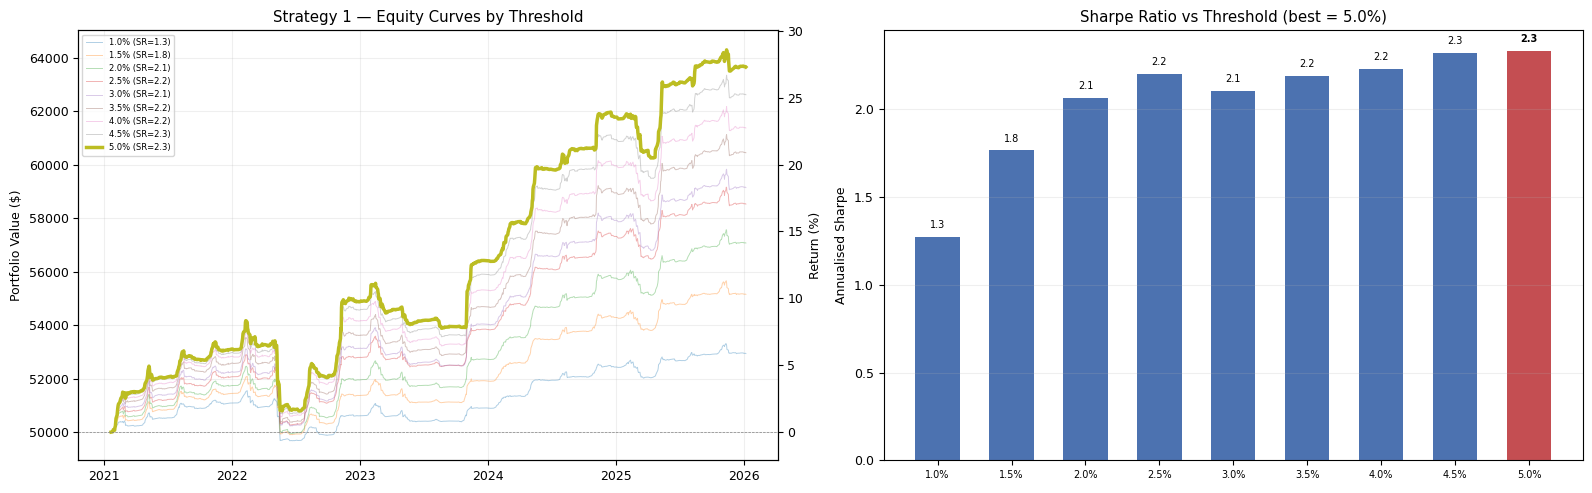


Threshold    Sharpe    Total P&L   Win Rate  Skipped
----------------------------------------------------
1.0%           1.27 $     2,868      86.2%        0
1.5%           1.77 $     4,921      80.6%        0
2.0%           2.07 $     6,637      75.9%        0
2.5%           2.20 $     7,903      71.5%        0
3.0%           2.10 $     8,436      67.5%        0
3.5%           2.19 $     9,531      65.0%        0
4.0%           2.23 $    10,298      63.0%        0
4.5%           2.32 $    11,309      61.7%        7
5.0%           2.33 $    12,138      60.7%       13 ← BEST


In [63]:
# ── Equity curves overlay (all thresholds) ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for r in results_s1:
    label = f"{r['threshold']:.1%} (SR={r['sharpe']:.1f})"
    lw = 2.5 if r["threshold"] == BEST_T else 0.7
    alpha = 1.0 if r["threshold"] == BEST_T else 0.35
    ax1.plot(r["dates"], r["equity"], label=label, lw=lw, alpha=alpha)

ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax1.set_title("Strategy 1 — Equity Curves by Threshold")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=6, loc="upper left")
ax1.grid(alpha=0.2)

# ── Twin axis: % return ───────────────────────────────────────────────
ax1b = ax1.twinx()
y1_min, y1_max = ax1.get_ylim()
ax1b.set_ylim(100 * (y1_min / INITIAL_CAPITAL - 1), 100 * (y1_max / INITIAL_CAPITAL - 1))
ax1b.set_ylabel("Return (%)")

# ── Sharpe vs Threshold ───────────────────────────────────────────────
T_list = [r["threshold"] for r in results_s1]
sr_list = [r["sharpe"] for r in results_s1]
pnl_list = [r["total_pnl"] for r in results_s1]
colors = ["#4C72B0" if i != best_idx else "#C44E52" for i in range(len(results_s1))]
ax2.bar(range(len(T_list)), sr_list, color=colors, width=0.6)
ax2.set_xticks(range(len(T_list)))
ax2.set_xticklabels([f"{t:.1%}" for t in T_list], fontsize=7)
ax2.set_title(f"Sharpe Ratio vs Threshold (best = {BEST_T:.1%})")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, (sr, pnl) in enumerate(zip(sr_list, pnl_list)):
    ax2.text(i, sr + 0.05, f"{sr:.1f}", ha="center", fontsize=7,
             fontweight="bold" if i == best_idx else "normal")
plt.tight_layout()
plt.show()

# ── Threshold summary table ───────────────────────────────────────────
print(f"\n{'Threshold':<10} {'Sharpe':>8} {'Total P&L':>12} {'Win Rate':>10} {'Skipped':>8}")
print(f"{'-'*52}")
for r in results_s1:
    marker = " ← BEST" if r["threshold"] == BEST_T else ""
    print(f"{r['threshold']:<10.1%} {r['sharpe']:>8.2f} ${r['total_pnl']:>10,.0f}"
          f" {r['win_rate']:>10.1%} {r['n_skipped']:>8}{marker}")

---
## 3b. Yearly & Quarterly Summary (Best Threshold)


In [64]:
# Build per-trade DataFrame for the best threshold
pnl_best, sell_date_best = compute_strat1_pnl(BEST_T)
pnl_best, sell_date_best, _ = filter_by_cash(pnl_best, sell_date_best, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)

trades_best = pl.DataFrame({
    "sell_date": sell_date_best.tolist(),
    "pnl": pnl_best,
}).with_columns(
    pl.col("sell_date").cast(pl.Date),
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("pnl") > 0).alias("is_win"),
)

# Yearly summary
yearly = trades_best.group_by("year").agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort("year")

print("Year  Trades    P&L ($)   Avg P&L  Win Rate")
print("-" * 48)
for row in yearly.iter_rows():
    yr, n, pnl_val, avg, wr = row
    print(f"{yr:<6} {n:>5} {pnl_val:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

# Quarterly summary
quarterly = trades_best.group_by(["year", "quarter"]).agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort(["year", "quarter"])

quarterly = quarterly.with_columns(
    (pl.col("year").cast(pl.Utf8) + " Q" + pl.col("quarter").cast(pl.Utf8)).alias("label")
)

print("\nQuarter   Trades    P&L ($)   Avg P&L  Win Rate")
print("-" * 52)
for row in quarterly.iter_rows():
    yr, q, n, pnl_val, avg, wr = row[:6]
    label = str(yr) + " Q" + str(q)
    print(f"{label:<10} {n:>5} {pnl_val:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

Year  Trades    P&L ($)   Avg P&L  Win Rate
------------------------------------------------
2021    1609     +3,018     +1.88     61.7%
2022    1791     +1,662     +0.93     60.4%
2023    1294     +1,393     +1.08     56.6%
2024    1666     +4,552     +2.73     66.1%
2025    1842     +1,525     +0.83     58.3%
2026       6        -11     -1.89     33.3%

Quarter   Trades    P&L ($)   Avg P&L  Win Rate
----------------------------------------------------
2021 Q1      477     +1,481     +3.10     68.8%
2021 Q2      385       +527     +1.37     57.7%
2021 Q3      472       +645     +1.37     59.7%
2021 Q4      275       +364     +1.32     58.2%
2022 Q1      485       +140     +0.29     56.3%
2022 Q2      483     -2,292     -4.75     36.2%
2022 Q3      328     +1,159     +3.53     74.1%
2022 Q4      495     +2,655     +5.36     78.8%
2023 Q1      487       -298     -0.61     43.1%
2023 Q2      305       -337     -1.11     50.2%
2023 Q3       74       -207     -2.79     47.3%
2023 Q4      

---
## 4. Strategy 2 — Half-Scale Exit

Sell 50% at half-threshold, remaining 50% at full threshold (or t+10 if never hit).
If half-threshold is never reached, entire position exits at t+10 close.

In [65]:
HALF_T = BEST_T / 2

# ── Check crossings ───────────────────────────────────────────────────
half_crossed = cummax_rets > HALF_T
half_idx = np.argmax(half_crossed, axis=1)
half_did = half_crossed[np.arange(N), half_idx]

full_crossed = cummax_rets > BEST_T
full_idx = np.argmax(full_crossed, axis=1)
full_did = full_crossed[np.arange(N), full_idx]

# ── Build exit records (1 or 2 per trade) ─────────────────────────────
half_amt = POSITION_SIZE / 2
pnl_list = []
entry_list = []
sell_list = []

for i in range(N):
    if half_did[i]:
        entry_list.append(entry_dates[i])
        pnl_list.append(half_amt * HALF_T)
        sell_list.append(drift_dates[i, half_idx[i]])
        if full_did[i]:
            entry_list.append(entry_dates[i])
            pnl_list.append(half_amt * BEST_T)
            sell_list.append(drift_dates[i, full_idx[i]])
        else:
            entry_list.append(entry_dates[i])
            pnl_list.append(half_amt * close_t10_ret[i])
            sell_list.append(close_t10_date[i])
    else:
        entry_list.append(entry_dates[i])
        pnl_list.append(POSITION_SIZE * close_t10_ret[i])
        sell_list.append(close_t10_date[i])

entry_s2 = np.array(entry_list)
pnl_s2 = np.array(pnl_list)
sell_s2 = np.array(sell_list)

# ── Apply cash filter, but Strat 2 uses per-leg entry (each leg is $50) ──
# For simplicity: treat each leg as an independent entry of size $50
pnl_s2, sell_s2, skipped_s2 = filter_by_cash(pnl_s2, sell_s2, entry_s2, INITIAL_CAPITAL, half_amt)

dates_s2, daily_rets_s2, equity_s2 = build_daily_equity(pnl_s2, sell_s2, INITIAL_CAPITAL)
sr_s2 = sharpe_annualised(daily_rets_s2)

print(f"Strategy 2  (T={BEST_T:.1%}, half={HALF_T:.1%}):")
print(f"  Exit events:  {len(pnl_s2):,} (skipped: {skipped_s2})")
print(f"  Sharpe:       {sr_s2:.2f}")
print(f"  Total P&L:    ${pnl_s2.sum():,.0f}")
print(f"  Win rate:     {(pnl_s2 > 0).mean():.2%}")
print(f"\nExit breakdown:")
print(f"  Half-threshold hit:     {half_did.sum():,}")
print(f"  Full threshold hit:     {(half_did & full_did).sum():,}")
print(f"  Only half-threshold:    {(half_did & ~full_did).sum():,}")
print(f"  Neither threshold:      {(~half_did).sum():,}")

Strategy 2  (T=5.0%, half=2.5%):
  Exit events:  13,642 (skipped: 0)
  Sharpe:       2.24
  Total P&L:    $10,004
  Win rate:     76.29%

Exit breakdown:
  Half-threshold hit:     5,421
  Full threshold hit:     3,120
  Only half-threshold:    2,301
  Neither threshold:      2,800


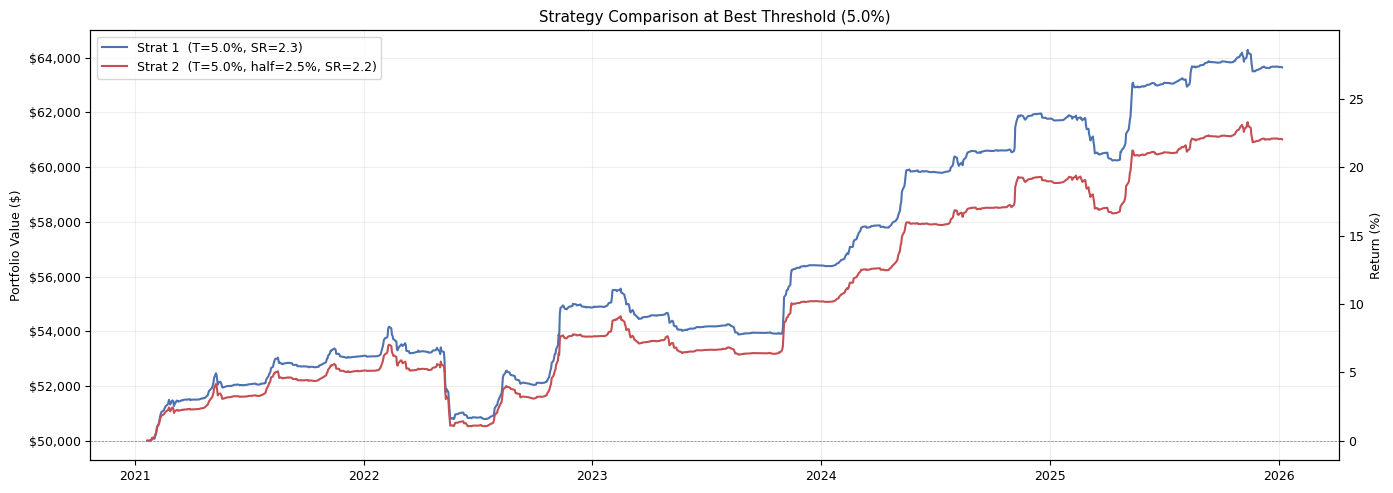


                  Sharpe    Total P&L   Win Rate    Exits
---------------------------------------------------------
Strat 1             2.33 $    12,138      60.7%     8208
Strat 2             2.24 $    10,004      76.3%   13,642


In [66]:
# ── Compare Strat 1 vs Strat 2 equity curves ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(best["dates"], best["equity"], color="#4C72B0", lw=1.5,
        label=f"Strat 1  (T={BEST_T:.1%}, SR={best['sharpe']:.1f})")
ax.plot(dates_s2, equity_s2, color="#C44E52", lw=1.5,
        label=f"Strat 2  (T={BEST_T:.1%}, half={HALF_T:.1%}, SR={sr_s2:.1f})")
ax.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax.set_title(f"Strategy Comparison at Best Threshold ({BEST_T:.1%})")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Twin axis: % return
axb = ax.twinx()
y1_min, y1_max = ax.get_ylim()
axb.set_ylim(100 * (y1_min / INITIAL_CAPITAL - 1), 100 * (y1_max / INITIAL_CAPITAL - 1))
axb.set_ylabel("Return (%)")

plt.tight_layout()
plt.show()

# ── Summary comparison ────────────────────────────────────────────────
print(f"\n{'':<15} {'Sharpe':>8} {'Total P&L':>12} {'Win Rate':>10} {'Exits':>8}")
print(f"{'-'*57}")
print(f"{'Strat 1':<15} {best['sharpe']:>8.2f} ${best['total_pnl']:>10,.0f} {best['win_rate']:>10.1%} {best['n_trades']:>8}")
print(f"{'Strat 2':<15} {sr_s2:>8.2f} ${pnl_s2.sum():>10,.0f} {(pnl_s2>0).mean():>10.1%} {len(pnl_s2):>8,}")

---
## Notes

- **Daily return** = (sum of P&L from trades closing today) / initial capital.
  Then equity compounds: `equity × (1 + return)` each active day, flat on inactive days.
- **Cash filter**: Trades are processed in entry-date order. If cash drops below
  `POSITION_SIZE`, subsequent trades are skipped (counted in `Sk` column).
  With $100/position and $50K capital, zero trades skip (max ~500 concurrent).
- **Sell dates** are exact — `date_t+{offset}` columns from daily OHLCV give
  actual calendar sell dates at the crossing day.
- **% Return**: right axis is scaled to match the dollar axis — 0% = $50K,
  10% = $55K, etc.
- **No slippage or commissions** are modeled. Add ~5-10 bps per trade for realism.